In [1]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

import torch
import hydra
from omegaconf import OmegaConf
from FASCINATION.src.utils import loading_datamodule, unorm_ssp_arr_3D
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

import numpy as np
from tqdm import tqdm
from scipy.ndimage import zoom
import pickle
import xarray as xr
from sklearn.decomposition import PCA

from pytorch_msssim import ms_ssim

from scipy.interpolate import interp1d

from scipy.ndimage import convolve

import pandas as pd



In [2]:
def cubic_interpolate_along_axis(arr: np.ndarray, target_size: int, axis: int) -> np.ndarray:
    """
    Interpolates a NumPy array along a specified axis using cubic splines.

    Parameters:
        arr (np.ndarray): Input array of arbitrary shape.
        target_size (int): Desired size along the interpolation axis.
        axis (int): Axis to interpolate along.

    Returns:
        np.ndarray: Interpolated array with the same shape except along `axis`.
    """
    original_shape = arr.shape
    current_size = arr.shape[axis]

    # Generate old and new coordinate grids normalized to [0, 1]
    x_old = np.linspace(0, 1, current_size)
    x_new = np.linspace(0, 1, target_size)

    # Move the axis to interpolate to the front for easier broadcasting
    arr_swapped = np.moveaxis(arr, axis, 0)  # Shape: (current_size, ...)
    reshaped = arr_swapped.reshape(current_size, -1)  # Shape: (current_size, -1)

    # Perform interpolation
    f = interp1d(x_old, reshaped, kind='cubic', axis=0, bounds_error=False, fill_value="extrapolate")
    interpolated = f(x_new)  # Shape: (target_size, -1)

    # Reshape back and move axis to original position
    new_shape = (target_size,) + arr_swapped.shape[1:]
    interpolated = interpolated.reshape(new_shape)
    return np.moveaxis(interpolated, 0, axis)

In [3]:
def get_f1_score(min_max_idx_truth, min_max_idx_ae, axs=1, kernel_size=10):



    # Define the kernel based on the shape of the truth array
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size  # Set the size of the kernel along the specified axis
    kernel = np.ones(kernel_shape)

    # Expand the truth array with the kernel
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)

    # Compute the true positives
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)

    # Compute the false positives
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)

    # Compute the false negatives
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)

    # Compute precision and recall while avoiding division by zero
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives

    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)

    # Compute f1_score and avoid division by zero when both precision and recall are 0
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)

    return f1_score

In [4]:
def get_min_max_idx(arr,axs=1, pad=True):
    grad = np.diff(arr,axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.diff(grad_sign,axis=axs) 
    min_max = np.abs(np.sign(min_max))
    if pad:
        min_max = np.pad(min_max, ((0,0),(1,1),(0,0),(0,0)), 'constant', constant_values=1)
    return min_max


In [5]:
def compute_psnr(a, b):
    mse = np.mean((a - b) ** 2)
    return -10 * np.log10(mse)

In [6]:

def compute_msssim(a, b):
    return ms_ssim(a, b, data_range=1.).item()

In [7]:

def compute_bpp(out_net):
    size = out_net['x_hat'].size()
    num_pixels = size[0] * size[2] * size[3]
    return sum(torch.log(likelihoods).sum() / (-math.log(2) * num_pixels)
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_total_bits(out_net):
    return sum(torch.log(likelihoods).sum() / (-math.log(2))
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_bits_per_sample(out_net):
    num_sample = out_net['x_hat'].size(0)
    return sum(torch.log(likelihoods).sum() / (-math.log(2)*num_sample)
              for likelihoods in out_net['likelihoods'].values()).item()

def compute_bits_per_elements(out_net):
    size = out_net['x_hat'].numel()
    return sum(torch.log(likelihoods).sum() / (-math.log(2) * size)
              for likelihoods in out_net['likelihoods'].values()).item()


def compute_compression_rate(out_net, bits_per_channel=8):
    original_bits = out_net['x_hat'].numel() * bits_per_channel
    compressed_bits = sum(
        -torch.log(likelihoods).sum() / math.log(2)
        for likelihoods in out_net['likelihoods'].values()
    ).item()
    return original_bits / compressed_bits

In [8]:
gpu = 0
    
if torch.cuda.is_available() and gpu is not None:
##This may not be necessary outside the notebook
    dev = f"cuda:{gpu}"
else:
    dev = "cpu"

device = torch.device(dev)

In [9]:
try:
    if dm_dict:
        print("Not reloading datamodule")

except:
    
    dm_dict = {}
    
    n_components = 0
    print("Initializing datamodule")

Initializing datamodule


In [10]:
data = "enatl"

In [11]:
data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
            "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}

In [12]:
xp="autoencoder_V2"

In [13]:
cfg_path = f"config/xp/{xp}.yaml"
cfg = OmegaConf.load(cfg_path)

In [14]:
cfg.paths.sound = data_path[data]

The images data have to be in the [0, 1] range

cf https://interdigitalinc.github.io/CompressAI/zoo.html#zoo-training

In [15]:
dm = hydra.utils.call(cfg.datamodule)

In [16]:
train_ssp_arr, test_ssp_arr, dm = loading_datamodule(dm)

dm_dict[cfg.datamodule] = dm

In [17]:
train_ssp_arr,test_ssp_arr = unorm_ssp_arr_3D(train_ssp_arr, dm), unorm_ssp_arr_3D(test_ssp_arr, dm)

In [18]:
train_ssp_arr.shape, test_ssp_arr.shape

((255, 157, 140, 240), (37, 157, 140, 240))

In [19]:
test_day, depth, height, width = test_ssp_arr.shape 
train_day= train_ssp_arr.shape[0]

In [20]:
depth_array = dm.depth_array

In [21]:
# Perform PCA over the depth dimension
explained_variance_threshold = 0.9

# Determine the number of components for depth PCA
depth_pca = PCA()
depth_pca.fit(train_ssp_arr.transpose(0, 2, 3, 1).reshape(-1, depth))
cumulative_variance_depth = np.cumsum(depth_pca.explained_variance_ratio_)
n = np.argmax(cumulative_variance_depth >= explained_variance_threshold) + 1

depth_pca = PCA(n_components=n)
train_depth_pca = depth_pca.fit_transform(train_ssp_arr.transpose(0, 2, 3, 1).reshape(-1, depth))
test_depth_pca = depth_pca.transform(test_ssp_arr.transpose(0, 2, 3, 1).reshape(-1, depth))

# Reshape back to original dimensions with reduced depth
train_ssp_arr_reduced_depth = train_depth_pca.reshape(train_day, height, width, n).transpose(0, 3, 1, 2)
test_ssp_arr_reduced_depth = test_depth_pca.reshape(test_day, height, width, n).transpose(0, 3, 1, 2)

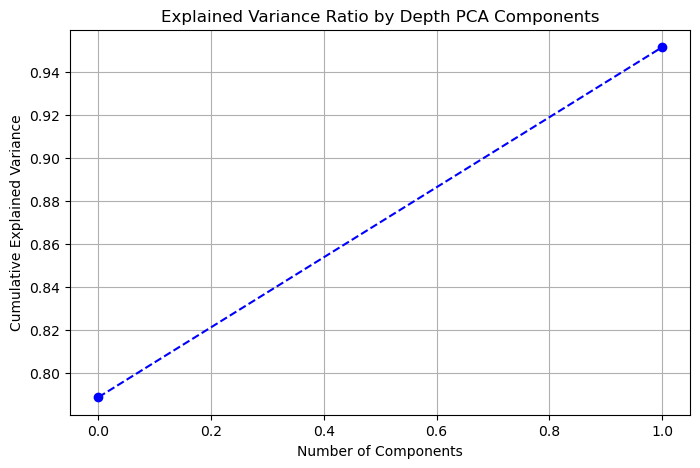

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(depth_pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.title('Explained Variance Ratio by Depth PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [23]:
# Perform PCA over the height*width dimensions

# Determine the number of components for spatial PCA
spatial_pca = PCA()
spatial_pca.fit(train_ssp_arr_reduced_depth.reshape(-1, height * width))
cumulative_variance_spatial = np.cumsum(spatial_pca.explained_variance_ratio_)
m = np.argmax(cumulative_variance_spatial >= explained_variance_threshold) + 1

spatial_pca = PCA(n_components=m)
train_spatial_pca = spatial_pca.fit_transform(train_ssp_arr_reduced_depth.reshape(-1, height * width))
test_spatial_pca = spatial_pca.transform(test_ssp_arr_reduced_depth.reshape(-1, height * width))

# Reshape back to original dimensions with reduced spatial dimensions
train_ssp_arr_reduced_spatial = train_spatial_pca.reshape(train_day, n, m).transpose(1, 2, 0)
test_ssp_arr_reduced_spatial = test_spatial_pca.reshape(test_day, n, m).transpose(1, 2, 0)

In [24]:
n,m

(2, 16)

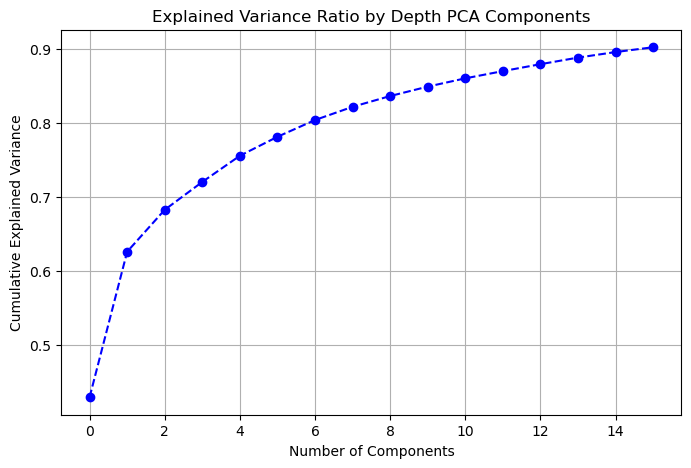

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(spatial_pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.title('Explained Variance Ratio by Depth PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [26]:
train_ssp_arr_reduced_spatial.shape 

(2, 16, 255)

In [27]:
test_ssp_arr_reduced_spatial.shape

(2, 16, 37)

In [28]:
test_ssp_arr_reduced_spatial.reshape(-1,test_day).shape 

(32, 37)

In [29]:
print(f"Shape after spatial PCA: {test_ssp_arr_reduced_spatial.shape}")

# Inverse transform the reduced spatial PCA
test_spatial_inverse = spatial_pca.inverse_transform(test_spatial_pca)
print(f"Shape after spatial PCA inverse transform: {test_spatial_inverse.shape}")

# Reshape back to reduced depth dimensions
test_ssp_arr_reconstructed_depth = test_spatial_inverse.reshape(test_day, n, height, width).transpose(0, 2, 3, 1)
print(f"Shape after reshaping to reduced depth dimensions: {test_ssp_arr_reconstructed_depth.shape}")

# Inverse transform the reduced depth PCA
test_depth_inverse = depth_pca.inverse_transform(test_ssp_arr_reconstructed_depth.reshape(-1, n))
print(f"Shape after depth PCA inverse transform: {test_depth_inverse.shape}")

# Reshape back to the original test_ssp_arr shape
test_ssp_arr_reconstructed = test_depth_inverse.reshape(test_day, height, width, depth).transpose(0, 3, 1, 2)
print(f"Shape after reshaping to original dimensions: {test_ssp_arr_reconstructed.shape}")

# Compute RMSE between the original and reconstructed test_ssp_arr
rmse = np.sqrt(np.mean((test_ssp_arr - test_ssp_arr_reconstructed) ** 2))
print(f"RMSE: {rmse}")


# Compute the size of the original and reduced arrays
original_size = test_ssp_arr.nbytes
reduced_size = test_ssp_arr_reduced_spatial.nbytes

# Calculate the compression rate
compression_rate = original_size / reduced_size
print(f"Compression Rate: {compression_rate:.2f}")

Shape after spatial PCA: (2, 16, 37)
Shape after spatial PCA inverse transform: (74, 33600)
Shape after reshaping to reduced depth dimensions: (37, 140, 240, 2)
Shape after depth PCA inverse transform: (1243200, 157)
Shape after reshaping to original dimensions: (37, 157, 140, 240)
RMSE: 2.8033023569153768
Compression Rate: 164850.00


In [56]:
explained_variance_thresholds = [0.5, 0.8, 0.9, 0.95, 0.98] #0.5, 0.8, 0.9, 0.95, 0.98,
pca_metrics_dict = {}

for threshold in tqdm(explained_variance_thresholds, desc="Processing thresholds", unit="threshold"):
    # ---- Depth PCA ----
    depth_pca = PCA()
    depth_pca.fit(train_ssp_arr.transpose(0, 2, 3, 1).reshape(-1, depth))
    cumulative_variance_depth = np.cumsum(depth_pca.explained_variance_ratio_)
    n = np.argmax(cumulative_variance_depth >= threshold) + 1

    depth_pca = PCA(n_components=n)
    train_depth_pca = depth_pca.fit_transform(train_ssp_arr.transpose(0, 2, 3, 1).reshape(-1, depth))
    test_depth_pca = depth_pca.transform(test_ssp_arr.transpose(0, 2, 3, 1).reshape(-1, depth))

    train_ssp_arr_reduced_depth = train_depth_pca.reshape(train_day, height, width, n).transpose(0, 3, 1, 2)
    test_ssp_arr_reduced_depth = test_depth_pca.reshape(test_day, height, width, n).transpose(0, 3, 1, 2)

    # ---- Spatial PCA ----
    spatial_pca = PCA()
    spatial_pca.fit(train_ssp_arr_reduced_depth.reshape(-1, height * width))
    cumulative_variance_spatial = np.cumsum(spatial_pca.explained_variance_ratio_)
    m = np.argmax(cumulative_variance_spatial >= threshold) + 1

    spatial_pca = PCA(n_components=m)
    train_spatial_pca = spatial_pca.fit_transform(train_ssp_arr_reduced_depth.reshape(-1, height * width))
    test_spatial_pca = spatial_pca.transform(test_ssp_arr_reduced_depth.reshape(-1, height * width))

    reduced_ssp_ae_test_arr = depth_pca.inverse_transform(
        spatial_pca.inverse_transform(test_spatial_pca)
        .reshape(test_day, n, height, width)
        .transpose(0, 2, 3, 1)
        .reshape(-1, n)
    ).reshape(test_day, height, width, depth).transpose(0, 3, 1, 2)

    # ---- Compression Rate ----
    original_size = test_ssp_arr.nbytes
    reduced_size = test_spatial_pca.nbytes
    cr = original_size / reduced_size

    # ---- Metrics ----
    max_ssp_truth_idx = np.nanargmax(test_ssp_arr, axis=1)
    ecs_truth = depth_array[max_ssp_truth_idx]

    psnr = compute_psnr(test_ssp_arr, reduced_ssp_ae_test_arr)
    msssim = compute_msssim(
        torch.tensor(cubic_interpolate_along_axis(test_ssp_arr, 161, axis=2), dtype=torch.float64),
        torch.tensor(cubic_interpolate_along_axis(reduced_ssp_ae_test_arr, 161, axis=2), dtype=torch.float64),
    )

    max_ssp_ae_idx = np.nanargmax(reduced_ssp_ae_test_arr, axis=1)
    ecs_pred_ae = depth_array[max_ssp_ae_idx]

    ae_ssp_rmse = np.sqrt(np.mean((test_ssp_arr - reduced_ssp_ae_test_arr) ** 2))
    ae_ecs_rmse = np.sqrt(np.mean((ecs_truth - ecs_pred_ae) ** 2))
    mae = np.mean(np.abs(test_ssp_arr - reduced_ssp_ae_test_arr))

    min_max_idx_truth = get_min_max_idx(test_ssp_arr, pad=False)
    min_max_idx_ae = get_min_max_idx(reduced_ssp_ae_test_arr, pad=False)
    mean_error_n_min_max = np.mean(np.abs(np.sum(min_max_idx_truth, axis=1) - np.sum(min_max_idx_ae, axis=1)))

    F1_score = get_f1_score(min_max_idx_truth, min_max_idx_ae)
    f1_score = np.mean(F1_score)

    r2 = 1 - (np.sum((test_ssp_arr - reduced_ssp_ae_test_arr) ** 2) /
              np.sum((test_ssp_arr - np.mean(test_ssp_arr)) ** 2))

    # Filtered F1
    # b, a = butter(N=2, Wn=0.107, btype='low', analog=False)
    # filtered_ae_test_arr = filtfilt(b, a, reduced_ssp_ae_test_arr[:, :-1, :, :], axis=1)
    # min_max_idx_filtered_ae = get_min_max_idx(filtered_ae_test_arr, pad=False)
    # filtered_F1_score = get_f1_score(min_max_idx_truth, min_max_idx_filtered_ae)
    # filtered_f1_score = np.mean(filtered_F1_score)

    # ---- Save metrics ----
    pca_metrics_dict[threshold] = {
        "CR": cr,
        "RMSE": ae_ssp_rmse,
        "PSNR": psnr,
        "MS-SSIM": msssim,
        "ECS": ae_ecs_rmse,
        "MAE": mae,
        "mean_error_n_min_max": mean_error_n_min_max,
        "F1_score": f1_score,
        "R2_score": r2
    }

#"Filtered_F1_score": filtered_f1_score,
# Display results

df_metrics = pd.DataFrame.from_dict(pca_metrics_dict, orient='index')
df_metrics


Processing thresholds:   0%|          | 0/5 [00:00<?, ?threshold/s]

/tmp/ipykernel_1807179/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_1807179/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
Processing thresholds:  20%|██        | 1/5 [07:57<31:50, 477.58s/threshold]/tmp/ipykernel_1807179/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_1807179/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
Processing thresholds:  40%|████      | 2/5 [16:15<24:29, 489.72s/threshold]/tmp/ipykernel_1807179/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den ==

,CR,RMSE,PSNR,MS-SSIM,ECS,MAE,mean_error_n_min_max,F1_score,R2_score
0.50,1.055040e+06,4.396561,-12.862261,0.642869,187.867688,2.949677,1.377386,0.372025,0.920669
0.80,3.768000e+05,3.416507,-10.671645,0.655022,118.514924,2.183834,1.597320,0.409203,0.952095
0.90,1.648500e+05,2.803282,-8.953337,0.724499,116.177054,1.854916,1.554976,0.434059,0.967749
0.95,9.420000e+04,2.398217,-7.597771,0.769397,113.526535,1.624954,1.522568,0.453118,0.976396
0.98,2.791111e+04,1.582107,-3.984718,0.848602,96.631155,1.061865,1.478810,0.527206,0.989727


In [57]:
df_metrics.to_csv("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics" + f"{xp}_pca_metrics.csv")

# Per season

In [9]:
data_path ={"enatl": "/Odyssey/public/enatl60/celerity/eNATL60_BLB002_sound_speed_regrid_0_botm.nc",
            "natl": "/Odyssey/public/natl60/celerity/NATL60GULF-CJM165_sound_speed_regrid_0_botm.nc"}

In [10]:
da_natl = xr.open_dataarray(data_path["natl"])
da_enatl = xr.open_dataarray(data_path["enatl"])

In [11]:
da_natl = da_natl.sel(z=da_natl.z[da_natl.z < 2000])
da_enatl = da_enatl.sel(z=da_enatl.z[da_enatl.z < 2000])


In [12]:
da_natl=da_natl.dropna(dim="lat")
da_enatl=da_enatl.dropna(dim="lat")

In [13]:
# Split DataArray into seasons for both NATL and eNATL

def assign_season(ds):
    """Assign a season label to each time in the DataArray."""
    month = ds['time.month']
    return xr.where(
        (month == 12) | (month <= 2), "winter",
        xr.where((month >= 3) & (month <= 5), "spring",
        xr.where((month >= 6) & (month <= 8), "summer", "autumn"))
    )

# Add a 'season' coordinate to both DataArrays
da_natl = da_natl.assign_coords(season=assign_season(da_natl))
da_enatl = da_enatl.assign_coords(season=assign_season(da_enatl))

# Split by season for NATL
da_natl_winter = da_natl.sel(time=da_natl['season'] == "winter")
da_natl_spring = da_natl.sel(time=da_natl['season'] == "spring")
da_natl_summer = da_natl.sel(time=da_natl['season'] == "summer")
da_natl_autumn = da_natl.sel(time=da_natl['season'] == "autumn")

# Split by season for eNATL
da_enatl_winter = da_enatl.sel(time=da_enatl['season'] == "winter")
da_enatl_spring = da_enatl.sel(time=da_enatl['season'] == "spring")
da_enatl_summer = da_enatl.sel(time=da_enatl['season'] == "summer")
da_enatl_autumn = da_enatl.sel(time=da_enatl['season'] == "autumn")

# Example: print number of time steps per season for eNATL
print("eNATL time steps per season:")
for season in ["winter", "spring", "summer", "autumn"]:
    print(season, da_enatl.sel(time=da_enatl['season'] == season).sizes['time'])

eNATL time steps per season:
winter 90
spring 92
summer 92
autumn 91


In [14]:
da_natl.shape,da_enatl.shape

((335, 157, 141, 240), (365, 157, 140, 240))

In [15]:
common_z = np.intersect1d(da_natl.z.values, da_enatl.z.values)
common_lat = np.intersect1d(da_natl.lat.values, da_enatl.lat.values)
common_lon = np.intersect1d(da_natl.lon.values, da_enatl.lon.values)

da_natl = da_natl.sel(z=common_z, lat=common_lat, lon=common_lon)
da_enatl = da_enatl.sel(z=common_z, lat=common_lat, lon=common_lon)


In [16]:

explained_variance_thresholds = [0.5, 0.8, 0.9, 0.95, 0.98]
season_metrics = {}

for season in tqdm(["winter", "spring", "summer", "autumn"], desc="Processing seasons", unit="season"):
    print(f"\nProcessing season: {season}")

    # Select season data and drop any missing values along time
    da_natl_season = da_natl.sel(time=da_natl['season'] == season).dropna(dim="time")
    da_enatl_season = da_enatl.sel(time=da_enatl['season'] == season).dropna(dim="time")

    # Ensure both have the same shape (time, z, lat, lon)
    min_time = min(da_natl_season.sizes["time"], da_enatl_season.sizes["time"])
    da_natl_season = da_natl_season.isel(time=slice(0, min_time))
    da_enatl_season = da_enatl_season.isel(time=slice(0, min_time))

    # Convert to numpy arrays
    natl_arr = da_natl_season.values  # (time, z, lat, lon)
    enatl_arr = da_enatl_season.values

    # Save original shapes
    t, z, lat, lon = natl_arr.shape

    season_metrics[season] = {}

    for threshold in tqdm(explained_variance_thresholds, desc="Processing thresholds", unit="threshold"):
        # ---- Depth PCA ----
        depth_pca = PCA()
        depth_pca.fit(natl_arr.transpose(0, 2, 3, 1).reshape(-1, z))
        cumulative_variance_depth = np.cumsum(depth_pca.explained_variance_ratio_)
        n = np.argmax(cumulative_variance_depth >= threshold) + 1

        depth_pca = PCA(n_components=n)
        natl_depth_pca = depth_pca.fit_transform(natl_arr.transpose(0, 2, 3, 1).reshape(-1, z))
        enatl_depth_pca = depth_pca.transform(enatl_arr.transpose(0, 2, 3, 1).reshape(-1, z))

        natl_arr_reduced_depth = natl_depth_pca.reshape(t, lat, lon, n).transpose(0, 3, 1, 2)
        enatl_arr_reduced_depth = enatl_depth_pca.reshape(t, lat, lon, n).transpose(0, 3, 1, 2)

        # ---- Spatial PCA ----
        spatial_pca = PCA()
        spatial_pca.fit(natl_arr_reduced_depth.reshape(-1, lat * lon))
        cumulative_variance_spatial = np.cumsum(spatial_pca.explained_variance_ratio_)
        m = np.argmax(cumulative_variance_spatial >= threshold) + 1

        spatial_pca = PCA(n_components=m)
        natl_spatial_pca = spatial_pca.fit_transform(natl_arr_reduced_depth.reshape(-1, lat * lon))
        enatl_spatial_pca = spatial_pca.transform(enatl_arr_reduced_depth.reshape(-1, lat * lon))

        natl_arr_reduced_spatial = natl_spatial_pca.reshape(t, n, m)
        enatl_arr_reduced_spatial = enatl_spatial_pca.reshape(t, n, m)

        # ---- Time PCA ----
        # Reshape to (n*m, t) for time PCA
        natl_arr_time = natl_arr_reduced_spatial.transpose(1, 2, 0).reshape(n * m, t).T  # (t, n*m)
        enatl_arr_time = enatl_arr_reduced_spatial.transpose(1, 2, 0).reshape(n * m, t).T

        time_pca = PCA()
        time_pca.fit(natl_arr_time)
        cumulative_variance_time = np.cumsum(time_pca.explained_variance_ratio_)
        k = np.argmax(cumulative_variance_time >= threshold) + 1

        time_pca = PCA(n_components=k)
        natl_time_pca = time_pca.fit_transform(natl_arr_time)
        enatl_time_pca = time_pca.transform(enatl_arr_time)

        # Inverse transform for reconstruction (on eNATL)
        enatl_time_recon = time_pca.inverse_transform(enatl_time_pca)  # (t, n*m)
        enatl_time_recon = enatl_time_recon.T.reshape(n, m, t).transpose(2, 0, 1)  # (t, n, m)

        # Inverse spatial PCA
        enatl_spatial_recon = spatial_pca.inverse_transform(enatl_time_recon.reshape(-1, m))
        enatl_spatial_recon = enatl_spatial_recon.reshape(t, n, lat, lon).transpose(0, 2, 3, 1)  # (t, lat, lon, n)

        # Inverse depth PCA
        enatl_depth_recon = depth_pca.inverse_transform(enatl_spatial_recon.reshape(-1, n))
        enatl_depth_recon = enatl_depth_recon.reshape(t, lat, lon, z).transpose(0, 3, 1, 2)  # (t, z, lat, lon)

        # ---- Metrics ----
        # Compute metrics between original and reconstructed eNATL
        arr_truth = enatl_arr
        arr_pred = enatl_depth_recon

        # Compression rate
        original_size = arr_truth.nbytes
        reduced_size = enatl_time_pca.nbytes
        cr = original_size / reduced_size

        # ECS
        max_ssp_truth_idx = np.nanargmax(arr_truth, axis=1)
        ecs_truth = da_enatl_season.z.values[max_ssp_truth_idx]
        max_ssp_pred_idx = np.nanargmax(arr_pred, axis=1)
        ecs_pred = da_enatl_season.z.values[max_ssp_pred_idx]

        # Metrics
        psnr = compute_psnr(arr_truth, arr_pred)
        msssim = compute_msssim(
            torch.tensor(cubic_interpolate_along_axis(arr_truth, 161, axis=2), dtype=torch.float64),
            torch.tensor(cubic_interpolate_along_axis(arr_pred, 161, axis=2), dtype=torch.float64),
        )
        ae_ssp_rmse = np.sqrt(np.mean((arr_truth - arr_pred) ** 2))
        ae_ecs_rmse = np.sqrt(np.mean((ecs_truth - ecs_pred) ** 2))
        mae = np.mean(np.abs(arr_truth - arr_pred))

        min_max_idx_truth = get_min_max_idx(arr_truth, pad=False)
        min_max_idx_pred = get_min_max_idx(arr_pred, pad=False)
        mean_error_n_min_max = np.mean(np.abs(np.sum(min_max_idx_truth, axis=1) - np.sum(min_max_idx_pred, axis=1)))

        F1_score = get_f1_score(min_max_idx_truth, min_max_idx_pred)
        f1_score = np.mean(F1_score)

        r2 = 1 - (np.sum((arr_truth - arr_pred) ** 2) /
                  np.sum((arr_truth - np.mean(arr_truth)) ** 2))

        # Save metrics
        season_metrics[season][threshold] = {
            "CR": cr,
            "RMSE": ae_ssp_rmse,
            "PSNR": psnr,
            "MS-SSIM": msssim,
            "ECS": ae_ecs_rmse,
            "MAE": mae,
            "mean_error_n_min_max": mean_error_n_min_max,
            "F1_score": f1_score,
            "R2_score": r2,
            "n_depth": n,
            "m_spatial": m,
            "k_time": k
        }

# Convert to DataFrame for each season
season_metrics_df = {season: pd.DataFrame.from_dict(season_metrics[season], orient='index') for season in season_metrics}
for season, df in season_metrics_df.items():
    print(f"\nMetrics for {season}:")
    display(df)


season_metrics_df.to_csv("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/visualisation/metrics" + f"all_pca_metrics_per_season.csv")

Processing seasons:   0%|          | 0/4 [00:00<?, ?season/s]


Processing season: winter


/tmp/ipykernel_2270330/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2270330/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
/tmp/ipykernel_2270330/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2270330/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
/tmp/ipykernel_2270330/4129993272.py:31: RuntimeWarning: invalid value encountered in divide
  recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
/tmp/ipykernel_2270330/4129993272.py:35: RuntimeWarning: invalid value encountered in divide
  f1_score = np.whe

KeyboardInterrupt: 